<>:135: SyntaxWarning: invalid escape sequence '\p'
<>:135: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_6388/479750383.py:135: SyntaxWarning: invalid escape sequence '\p'
  x_tick_labels = [f'${val}\pi$' if val != 0 else '0' for val in x_tick_values / np.pi]


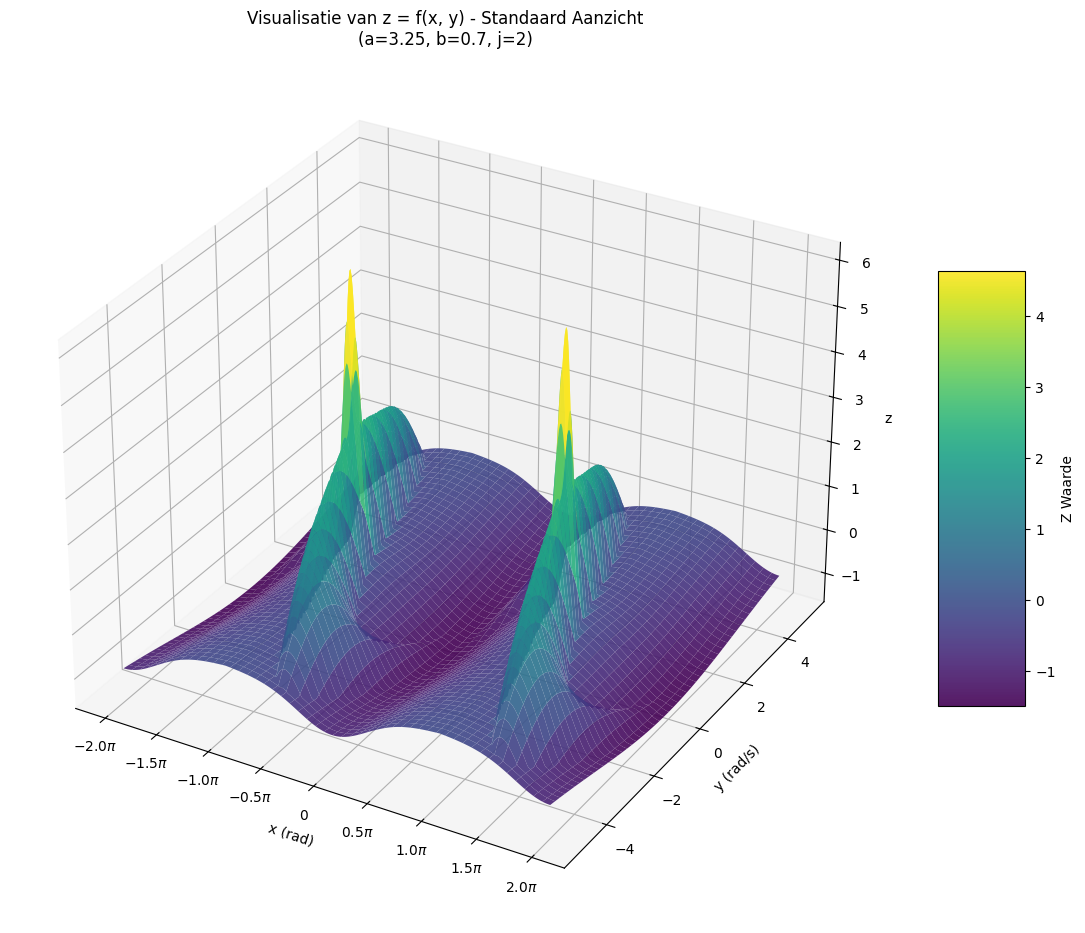

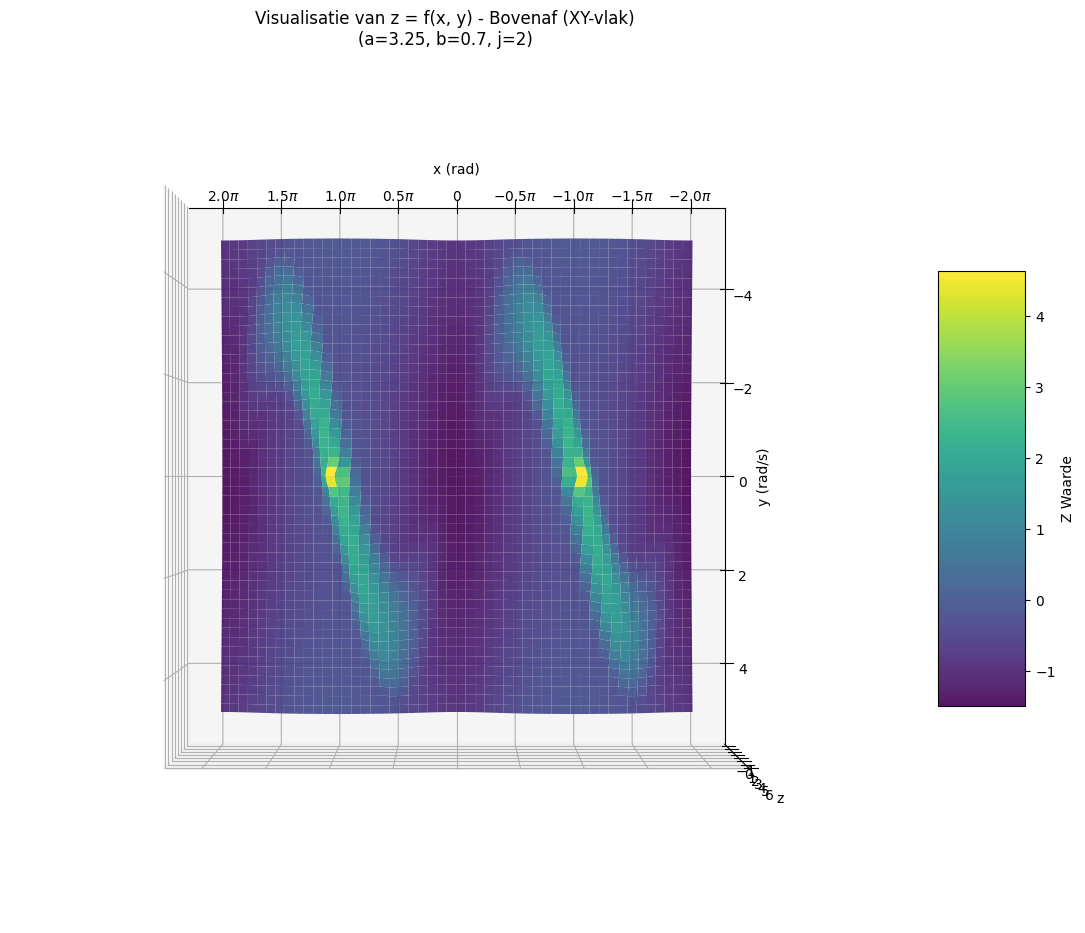

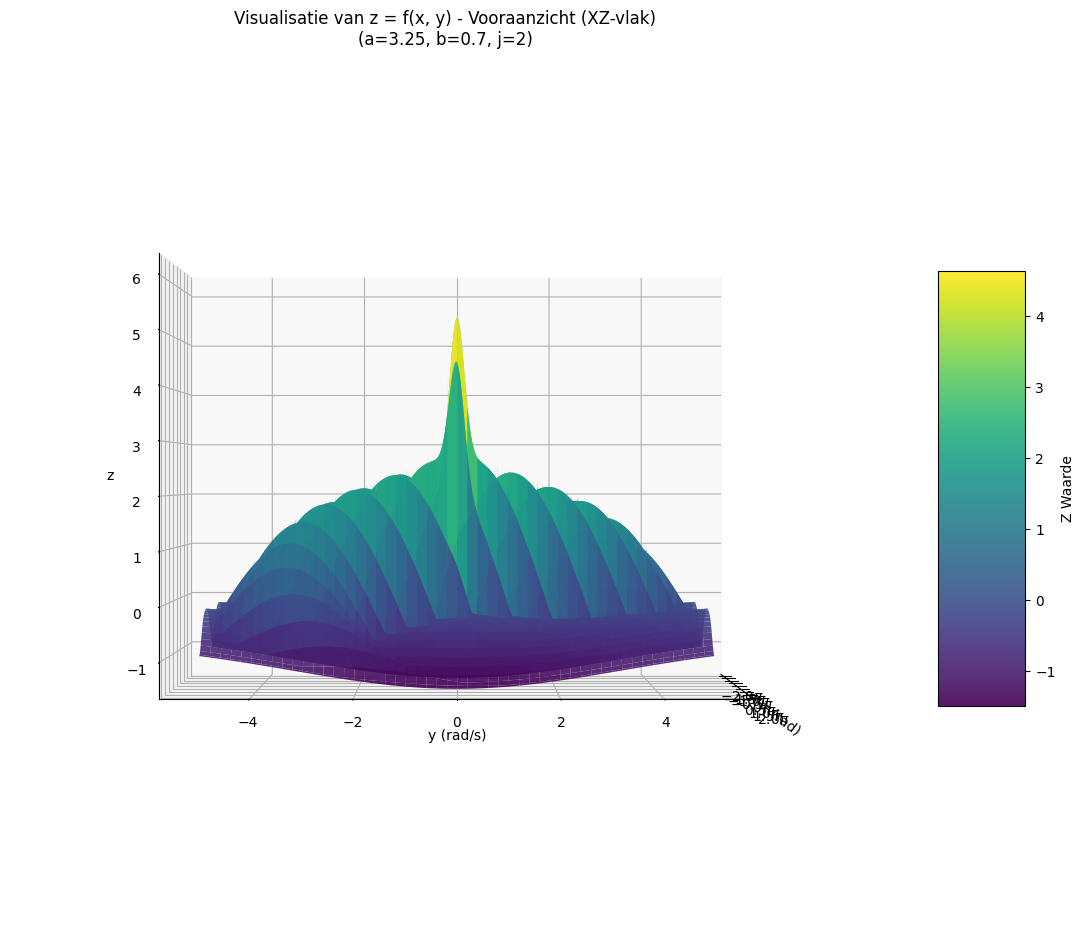

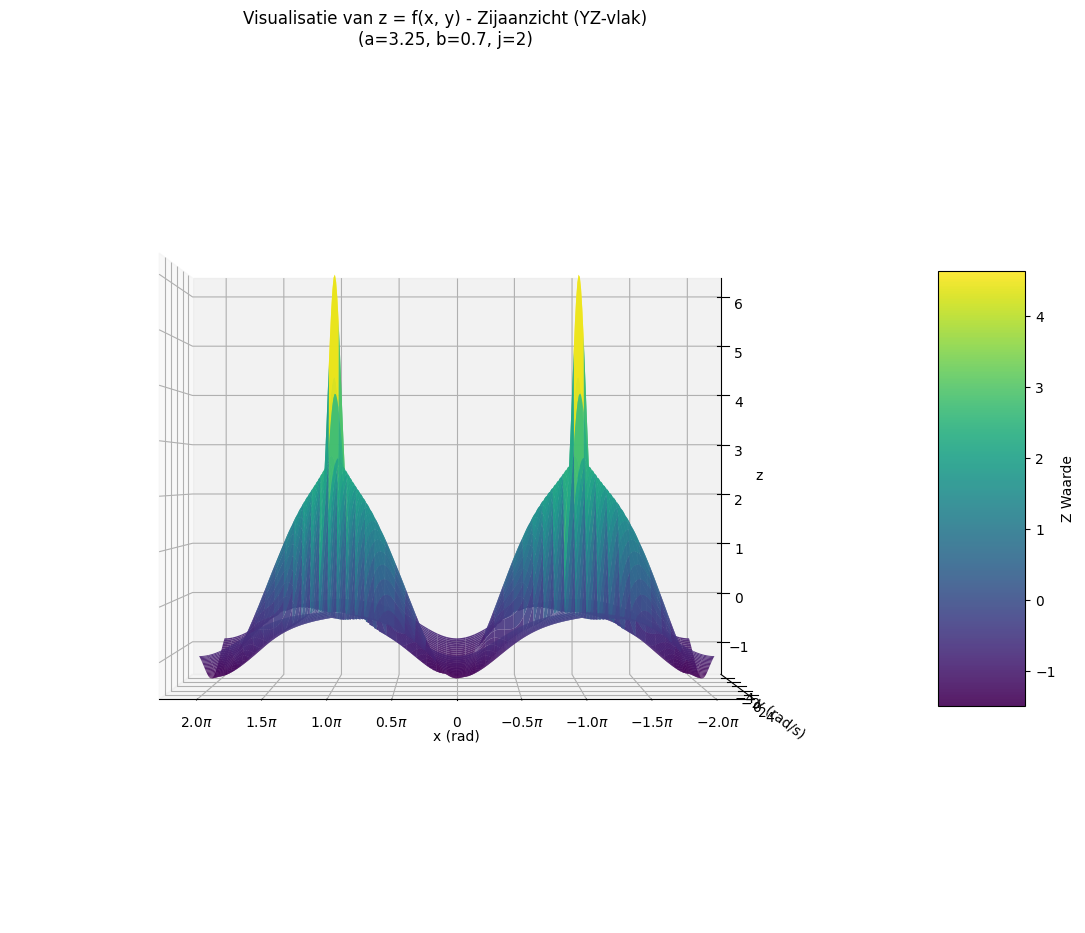

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Helper functies ---

def calculate_z(x, y, a, b, j):
    term1 = np.sin(y - np.sin(x) * a + 0.5 * np.pi)
    term2 = (j + np.sin(x - 0.5 * np.pi) * 2)
    
    z = term1 * b * term2

    # Toepassen van de voorwaarden
    # {sin(x) * a - pi <= y <= sin((x)) * a + pi}
    condition_y_lower = np.sin(x) * a - np.pi
    condition_y_upper = np.sin(x) * a + np.pi
    
    # {-j + 2 <= z}
    condition_z_lower = -j + 2

    # Maak een masker voor de punten die niet aan de voorwaarden voldoen
    # Als een punt niet aan de voorwaarden voldoet, wordt de waarde ervan NaN (Not a Number)
    # zodat deze niet wordt geplot.
    mask = (y >= condition_y_lower) & \
           (y <= condition_y_upper) & \
           (z >= condition_z_lower)
    
    z_filtered = np.where(mask, z, 0)
    return z_filtered

# Functie om de minimale hoekfout te berekenen (komt overeen met self.err)
def calculate_error(current_th, target_th):
    return np.abs(((current_th - target_th + np.pi) % (2 * np.pi)) - np.pi)

# Helper functie voor 2D Gaussian
def gaussian_2d(val_x, val_y, mu_x, mu_y, sigma_x, sigma_y, rho, scale):
    # Zorg ervoor dat inputs arrays zijn, zelfs als ze scalair zijn
    val_x = np.atleast_1d(val_x)
    val_y = np.atleast_1d(val_y)
    mu = np.array([mu_x, mu_y])
    cov = np.array([[sigma_x**2, rho * sigma_x * sigma_y],
                    [rho * sigma_x * sigma_y, sigma_y**2]])
    inv_cov = np.linalg.inv(cov)
    det_cov = np.linalg.det(cov)
    diff_x = val_x - mu[0]
    diff_y = val_y - mu[1]
    exponent = -0.5 * (inv_cov[0,0] * diff_x**2 +
                        (inv_cov[0,1] + inv_cov[1,0]) * diff_x * diff_y +
                        inv_cov[1,1] * diff_y**2)

    return scale * (1.0 / (2 * np.pi * np.sqrt(det_cov))) * np.exp(exponent)




A_VALUE = 3.25  # Voor 'a' in de formule
B_VALUE = 0.7  # Voor 'b' in de formule
J_VALUE = 2  # Voor 'j' in de formule







def reward_function_for_plot(th_val, omega_val, th_ref_val, u_val):
    main_reward_component = gaussian_2d(calculate_error(th_val, np.pi), omega_val, 0, 0, 1, 1, 0.0, 2)
    bottom_punishment_component = gaussian_2d(calculate_error(th_val, 0), omega_val, 0, 0, 3, 3, 0.0, 40)
    bottom_punishment_component_2 = gaussian_2d(calculate_error(th_val, 0), omega_val, 0, 0, 1, 12, 0.0, 60)
    piek_reward_component = gaussian_2d(calculate_error(th_val, np.pi), omega_val, 0, 0, 0.07, 0.07, 0.0, 0.15)
    piek_test = gaussian_2d(calculate_error(th_val, np.pi), omega_val, 0, 0, 0.15, 0.15, 0.0, 0.5)
    Z_VALUES = calculate_z(th_val, omega_val, a=A_VALUE, b=B_VALUE, j=J_VALUE)
    
    control_input_penalty = 0.001 * u_val**2
    # Combineer alle componenten
    total_reward = (
        main_reward_component
        - bottom_punishment_component
        - control_input_penalty
        - bottom_punishment_component_2
         + Z_VALUES
        #  + piek_reward_component
         + piek_test
    )
    return total_reward

# --- Plotting gedeelte ---






# Definieer de ranges voor de assen van de plot
# th_val: De hoek van je systeem, van -pi tot pi (een volledige cirkel)
th_plot_range = np.linspace(-2 * np.pi, 2 * np.pi, 400)
# omega_val: De hoeksnelheid
omega_plot_range = np.linspace(-5, 5, 400) 

# Creëer de meshgrid voor de plotassen
TH_MESH, OMEGA_MESH = np.meshgrid(th_plot_range, omega_plot_range)

# Kies de vaste waarden voor th_ref en u voor DÉZE specifieke plot
# Je kunt deze waarden aanpassen om te zien hoe de reward verandert
TH_REF_FOR_PLOT = 0.0 # Bijvoorbeeld, je referentiehoek is 0 radialen
U_FOR_PLOT = 0.5      # Bijvoorbeeld, een constante control input van 0.5

# Bereken de beloningswaarden over het hele grid, met de gekozen vaste waarden
Z_REWARD = reward_function_for_plot(TH_MESH, OMEGA_MESH, th_ref_val=TH_REF_FOR_PLOT, u_val=U_FOR_PLOT)


plot_views = [
    {'elev': 30, 'azim': -60, 'title_suffix': 'Standaard Aanzicht'},
    {'elev': 90, 'azim': 90, 'title_suffix': 'Bovenaf (XY-vlak)'},
    {'elev': 0, 'azim': 0, 'title_suffix': 'Vooraanzicht (XZ-vlak)'},
    {'elev': 0, 'azim': 90, 'title_suffix': 'Zijaanzicht (YZ-vlak)'}
]

for i, view in enumerate(plot_views):
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    plt.tight_layout()

    ax.set_xlabel('x (rad)')
    ax.set_ylabel('y (rad/s)')
    ax.set_zlabel('z')
    ax.set_title(f'Visualisatie van z = f(x, y) - {view["title_suffix"]}\n(a={A_VALUE}, b={B_VALUE}, j={J_VALUE})')

    # --- Aangepaste x-as labels in veelvouden van pi ---
    # Bepaal de locaties van de ticks (bijv. -2pi, -pi, 0, pi, 2pi)
    x_tick_values = np.array([-2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2]) * np.pi
    ax.set_xticks(x_tick_values)
    
    # Maak de labels voor de ticks (bijv. "-2π", "-π", "0", "π", "2π")
    x_tick_labels = [f'${val}\pi$' if val != 0 else '0' for val in x_tick_values / np.pi]
    ax.set_xticklabels(x_tick_labels)
    # --- Einde aangepaste x-as labels ---

    # Plot het oppervlak
    surf = ax.plot_surface(TH_MESH, OMEGA_MESH, Z_REWARD, cmap='viridis', edgecolor='none', alpha=0.9)
    fig.colorbar(surf, shrink=0.5, aspect=5, label='Z Waarde')

    # Stel het aanzicht in
    ax.view_init(elev=view['elev'], azim=view['azim'])

    plt.show()




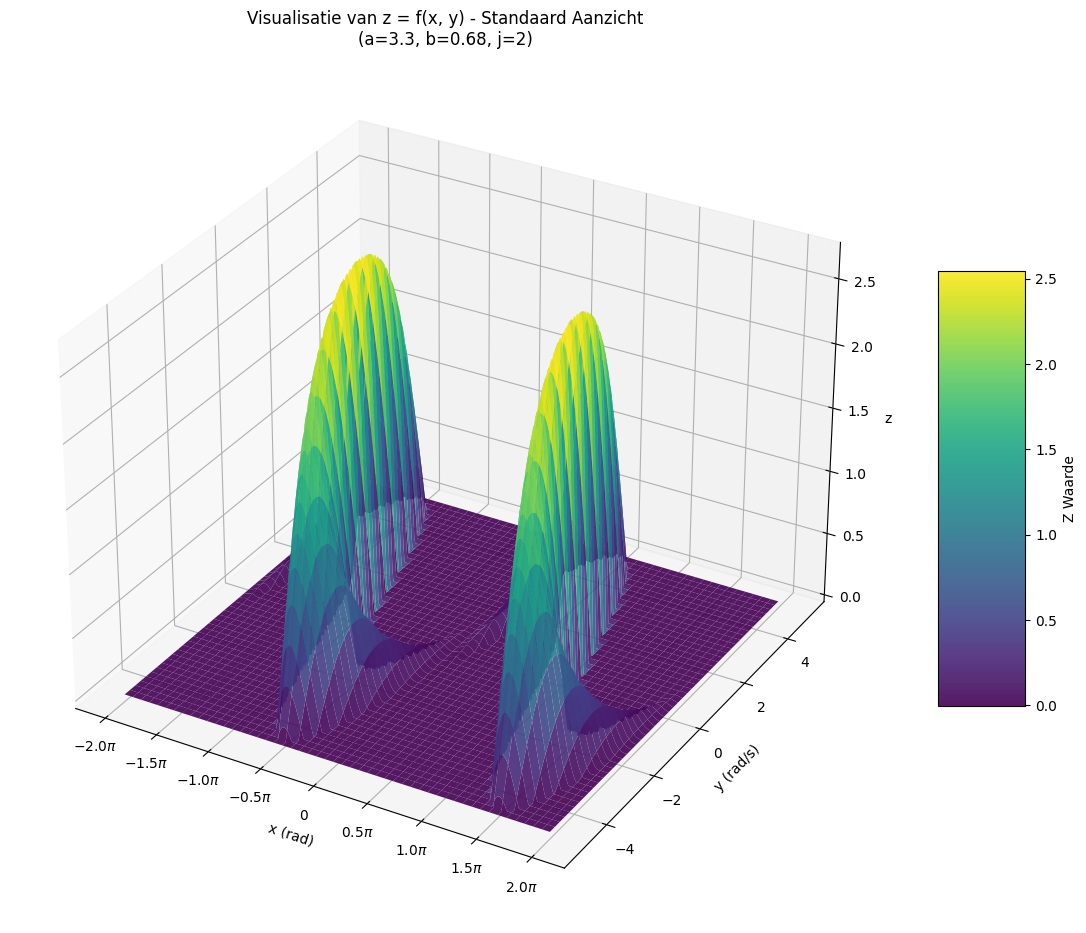

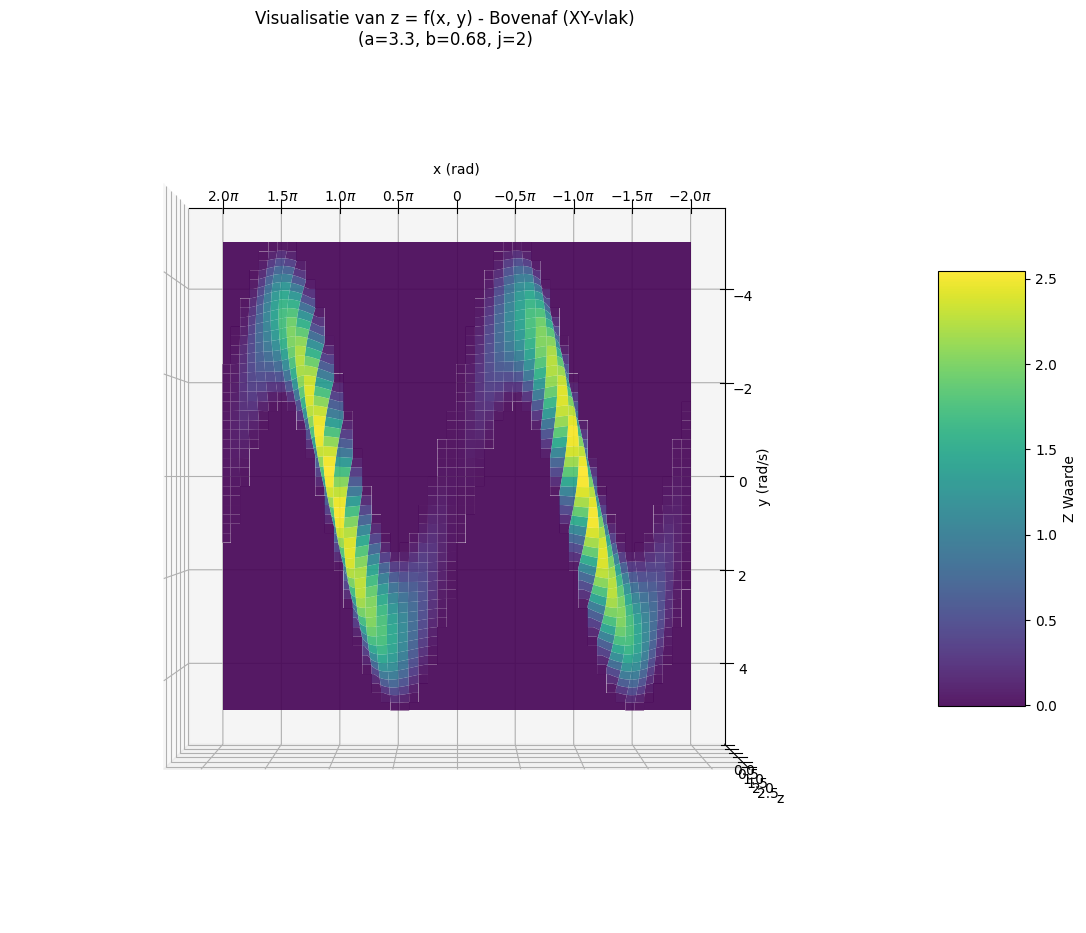

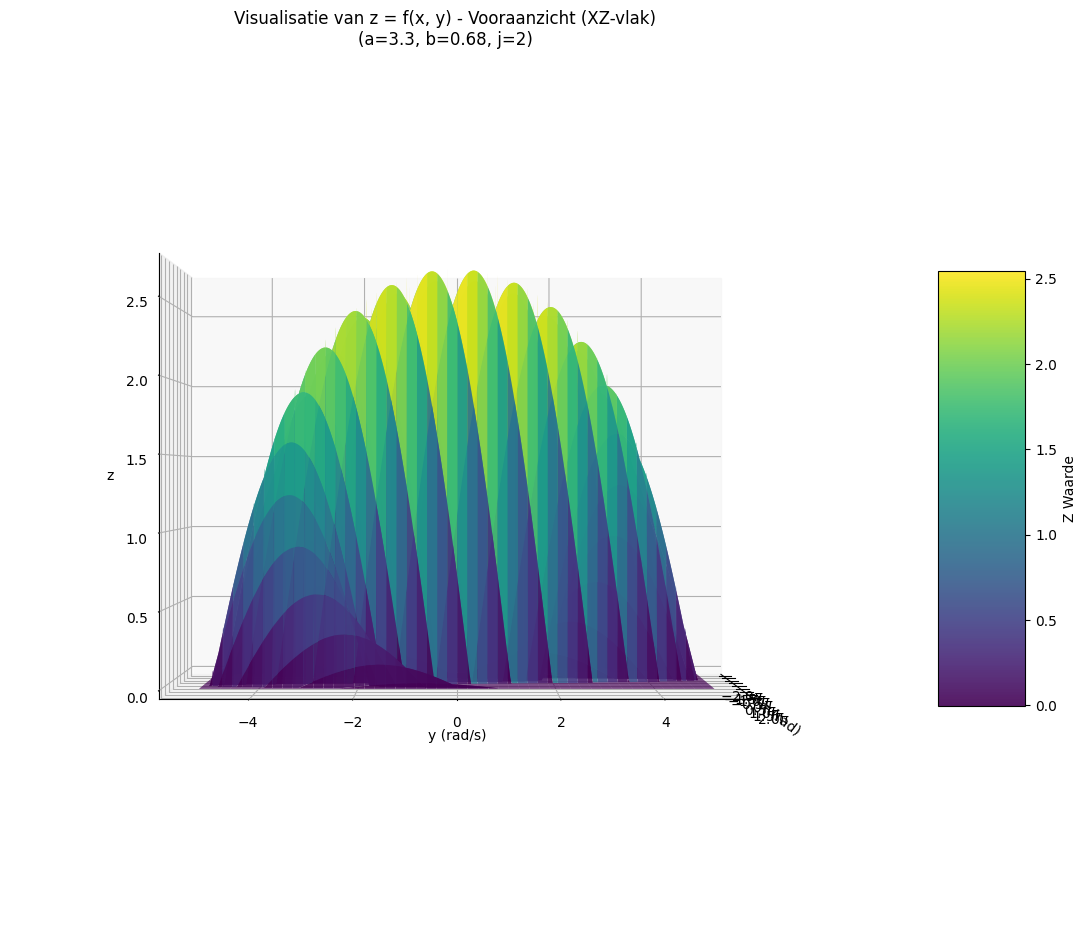

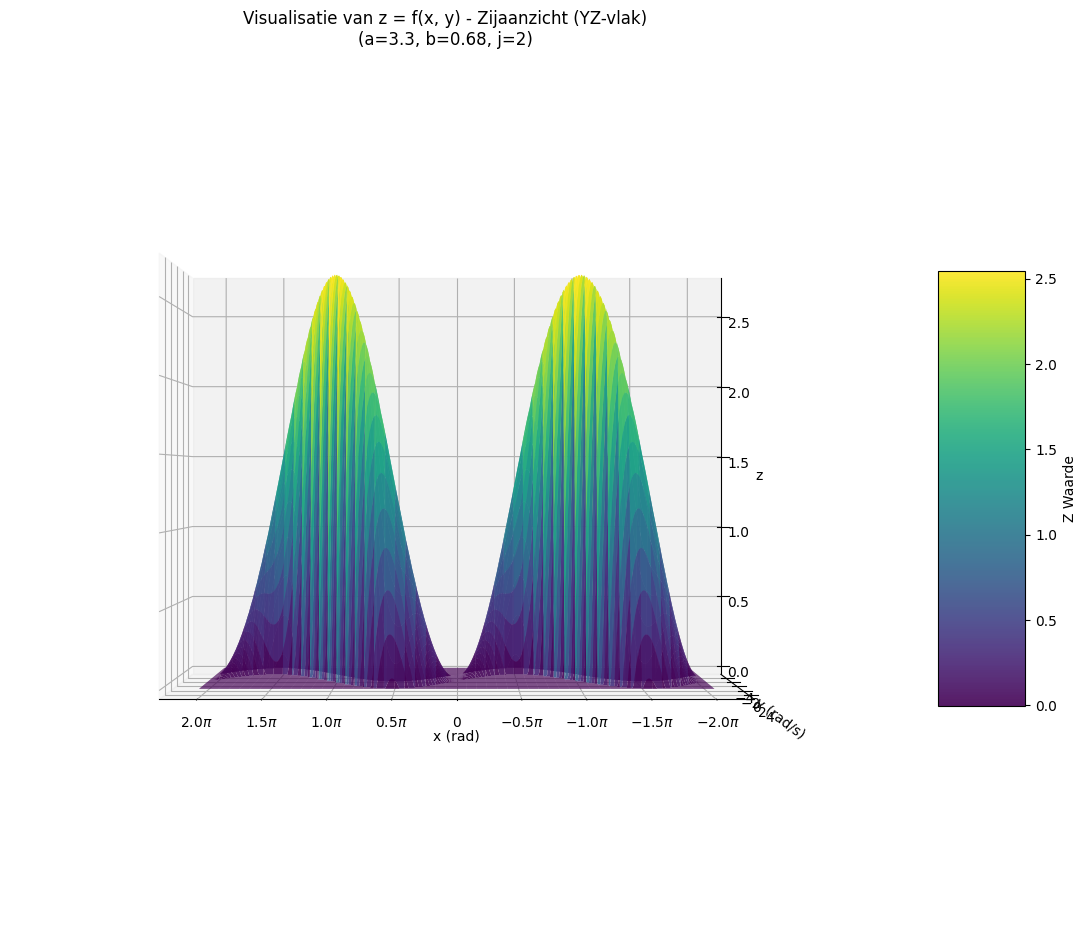

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Helper functies ---

def calculate_z(x, y, a, b, j):
    """
    Berekent de waarde van z op basis van de gegeven wiskundige formule.

    Parameters:
    x (numpy.array): De input array voor x (interpretatie: rad).
    y (numpy.array): De input array voor y (interpretatie: rad/s).
    a (float): Variabele 'a'.
    b (float): Variabele 'b'.
    j (float): Variabele 'j'.

    Returns:
    numpy.array: De berekende z-waarden.
    """
    # De hoofdberekening voor z
    term1 = np.sin(y - np.sin(x) * a + 0.5 * np.pi)
    term2 = (j + np.sin(x - 0.5 * np.pi) * 2)
    z = term1 * b * term2

    # Toepassen van de voorwaarden
    # {sin(x) * a - pi <= y <= sin((x)) * a + pi}
    condition_y_lower = np.sin(x) * a - np.pi
    condition_y_upper = np.sin(x) * a + np.pi
    
    # {-j + 2 <= z}
    condition_z_lower = -j + 2

    # Maak een masker voor de punten die niet aan de voorwaarden voldoen
    # Als een punt niet aan de voorwaarden voldoet, wordt de waarde ervan NaN (Not a Number)
    # zodat deze niet wordt geplot.
    mask = (y >= condition_y_lower) & \
           (y <= condition_y_upper) & \
           (z >= condition_z_lower)
    
    z_filtered = np.where(mask, z, 0)
    return z_filtered

# Functie om de minimale hoekfout te berekenen (komt overeen met self.err)
def calculate_error(current_th, target_th):
    return np.abs(((current_th - target_th + np.pi) % (2 * np.pi)) - np.pi)


A_VALUE = 3.3  # Voor 'a' in de formule
B_VALUE = 0.68  # Voor 'b' in de formule
J_VALUE = 2  # Voor 'j' in de formule







def reward_function_for_plot(th_val, omega_val, th_ref_val, u_val):
    Z_VALUES = calculate_z(th_val, omega_val, a=A_VALUE, b=B_VALUE, j=J_VALUE)
    
    control_input_penalty = 0.001 * u_val**2
    # Combineer alle componenten
    total_reward = (
        - control_input_penalty
         + Z_VALUES
    )
    return total_reward

# --- Plotting gedeelte ---






# Definieer de ranges voor de assen van de plot
# th_val: De hoek van je systeem, van -pi tot pi (een volledige cirkel)
th_plot_range = np.linspace(-2 * np.pi, 2 * np.pi, 400)
# omega_val: De hoeksnelheid
omega_plot_range = np.linspace(-5, 5, 400) 

# Creëer de meshgrid voor de plotassen
TH_MESH, OMEGA_MESH = np.meshgrid(th_plot_range, omega_plot_range)

# Kies de vaste waarden voor th_ref en u voor DÉZE specifieke plot
# Je kunt deze waarden aanpassen om te zien hoe de reward verandert
TH_REF_FOR_PLOT = 0.0 # Bijvoorbeeld, je referentiehoek is 0 radialen
U_FOR_PLOT = 0.5      # Bijvoorbeeld, een constante control input van 0.5

# Bereken de beloningswaarden over het hele grid, met de gekozen vaste waarden
Z_REWARD = reward_function_for_plot(TH_MESH, OMEGA_MESH, th_ref_val=TH_REF_FOR_PLOT, u_val=U_FOR_PLOT)


plot_views = [
    {'elev': 30, 'azim': -60, 'title_suffix': 'Standaard Aanzicht'},
    {'elev': 90, 'azim': 90, 'title_suffix': 'Bovenaf (XY-vlak)'},
    {'elev': 0, 'azim': 0, 'title_suffix': 'Vooraanzicht (XZ-vlak)'},
    {'elev': 0, 'azim': 90, 'title_suffix': 'Zijaanzicht (YZ-vlak)'}
]

for i, view in enumerate(plot_views):
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    plt.tight_layout()

    ax.set_xlabel('x (rad)')
    ax.set_ylabel('y (rad/s)')
    ax.set_zlabel('z')
    ax.set_title(f'Visualisatie van z = f(x, y) - {view["title_suffix"]}\n(a={A_VALUE}, b={B_VALUE}, j={J_VALUE})')

    # --- Aangepaste x-as labels in veelvouden van pi ---
    # Bepaal de locaties van de ticks (bijv. -2pi, -pi, 0, pi, 2pi)
    x_tick_values = np.array([-2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2]) * np.pi
    ax.set_xticks(x_tick_values)
    
    # Maak de labels voor de ticks (bijv. "-2π", "-π", "0", "π", "2π")
    x_tick_labels = [f'${val}\pi$' if val != 0 else '0' for val in x_tick_values / np.pi]
    ax.set_xticklabels(x_tick_labels)
    # --- Einde aangepaste x-as labels ---

    # Plot het oppervlak
    surf = ax.plot_surface(TH_MESH, OMEGA_MESH, Z_REWARD, cmap='viridis', edgecolor='none', alpha=0.9)
    fig.colorbar(surf, shrink=0.5, aspect=5, label='Z Waarde')

    # Stel het aanzicht in
    ax.view_init(elev=view['elev'], azim=view['azim'])

    plt.show()




<>:121: SyntaxWarning: invalid escape sequence '\p'
<>:121: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_48617/2605946882.py:121: SyntaxWarning: invalid escape sequence '\p'
  x_tick_labels = [f'${val}\pi$' if val != 0 else '0' for val in x_tick_values / np.pi]


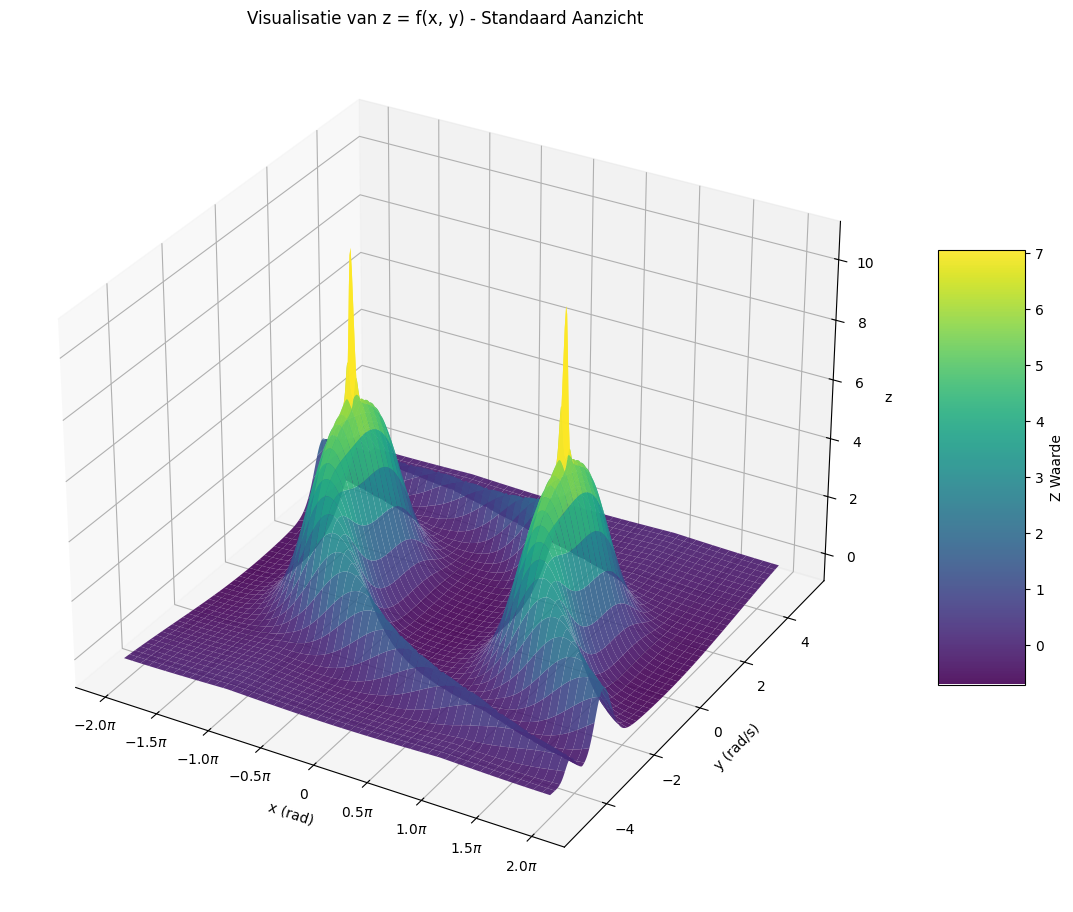

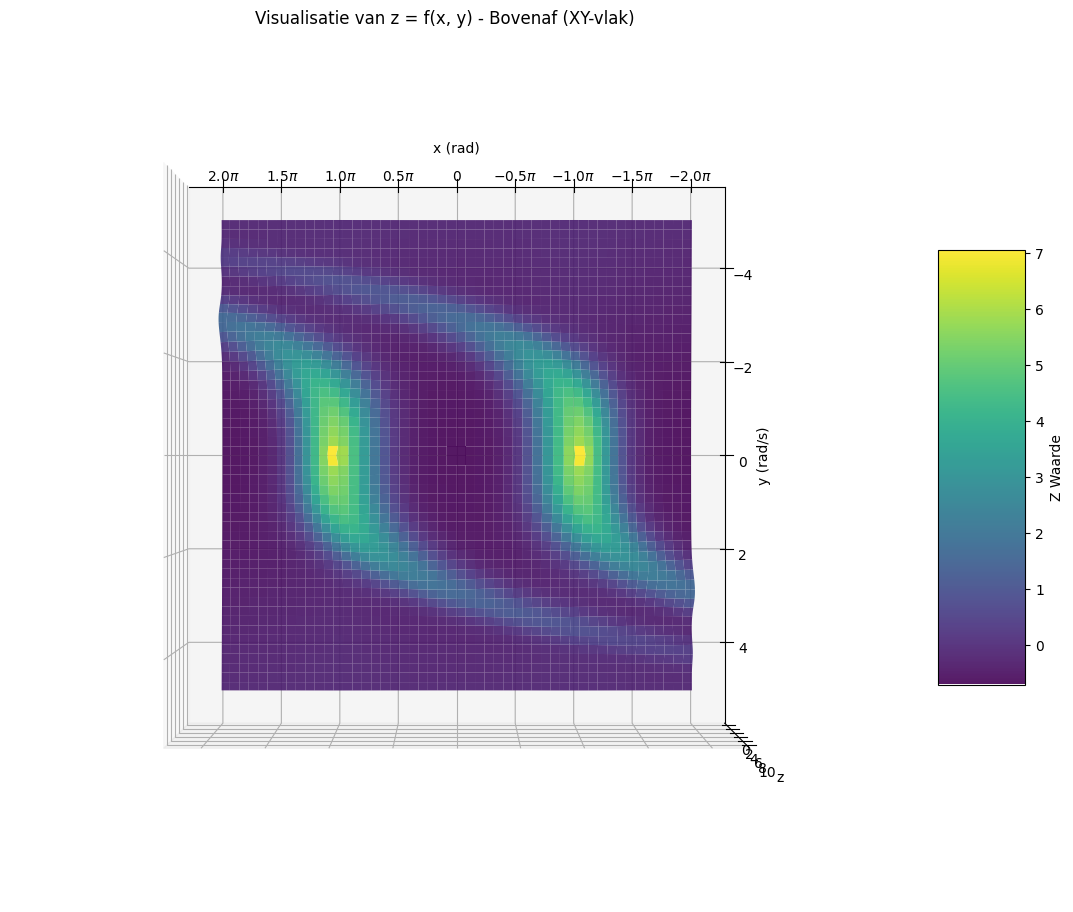

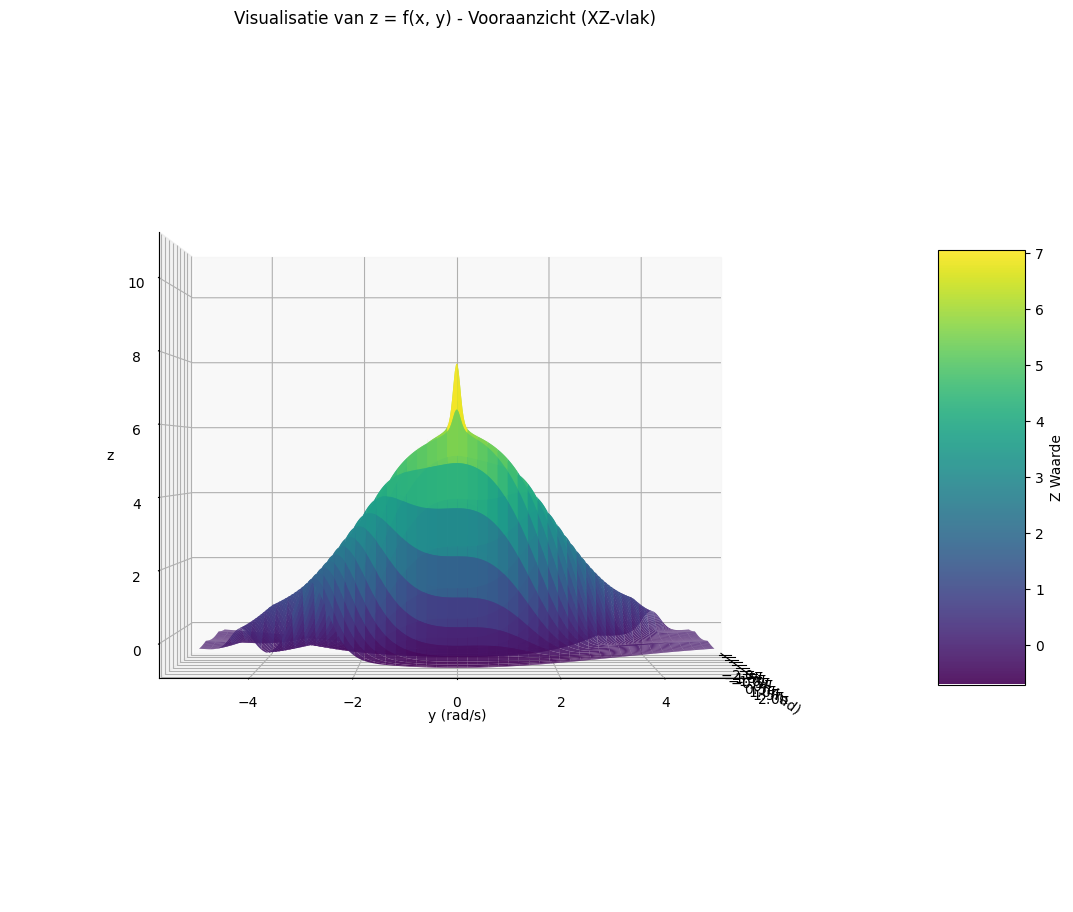

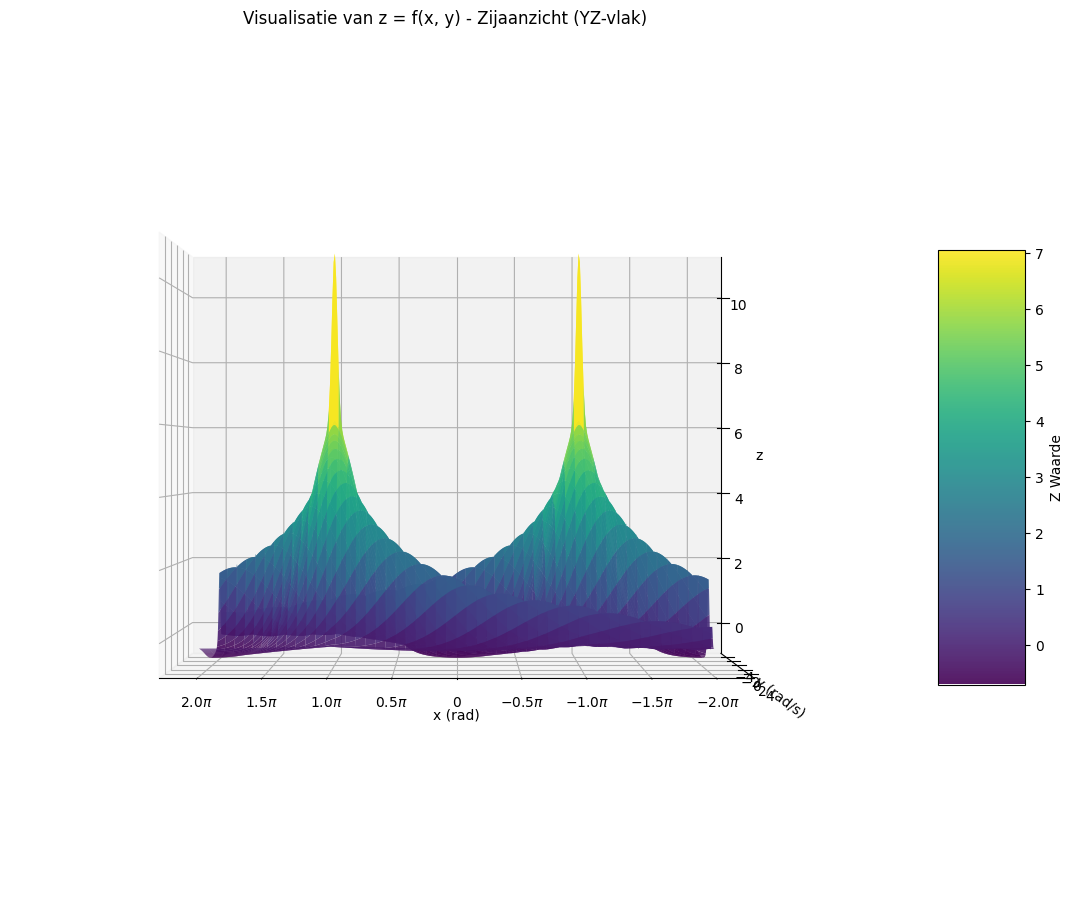

<>:127: SyntaxWarning: invalid escape sequence '\p'
<>:127: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_60216/2431765580.py:127: SyntaxWarning: invalid escape sequence '\p'
  x_tick_labels = [f'${val}\pi$' if val != 0 else '0' for val in x_tick_values / np.pi]


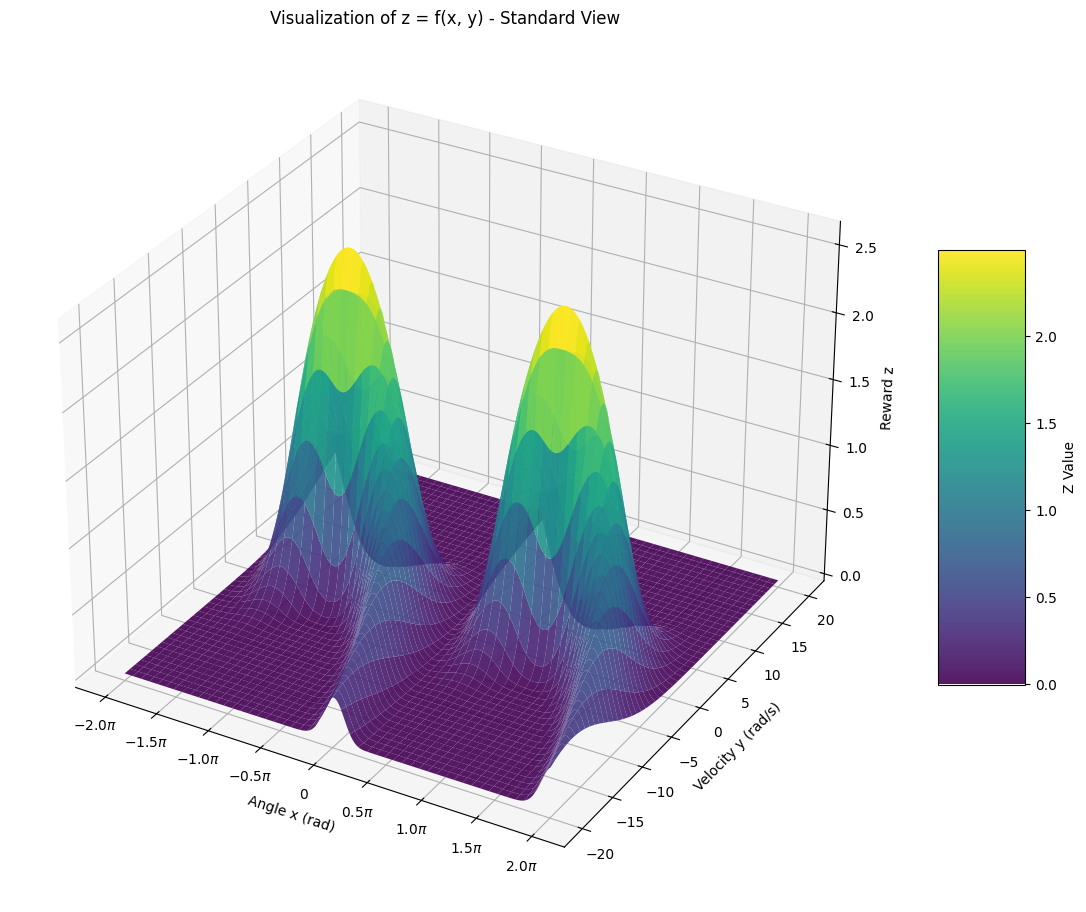

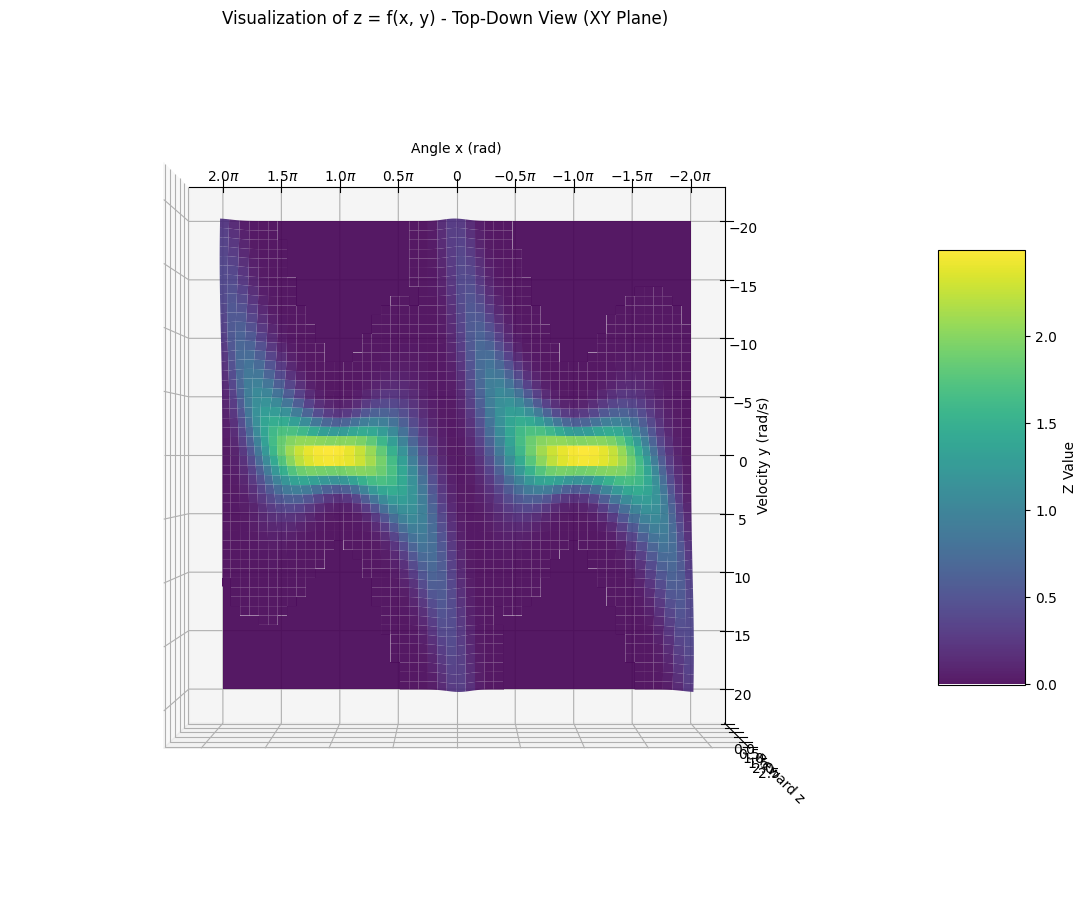

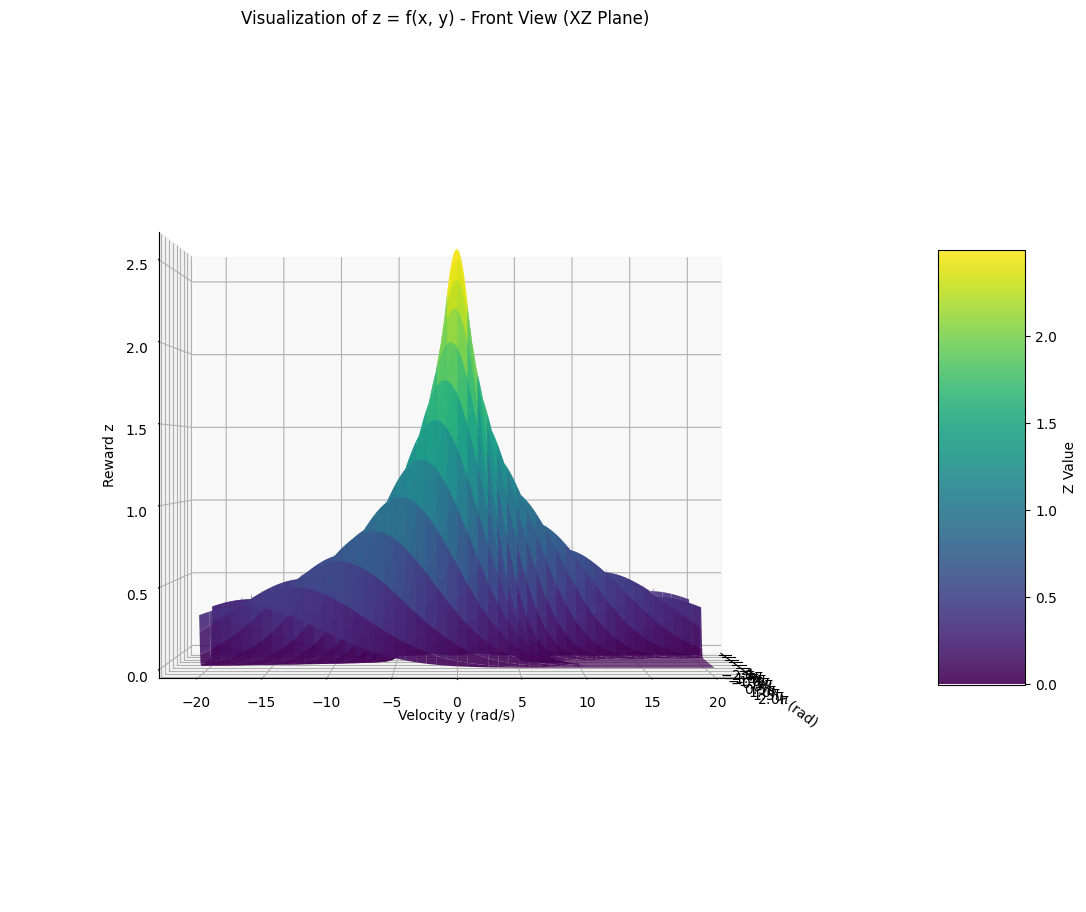

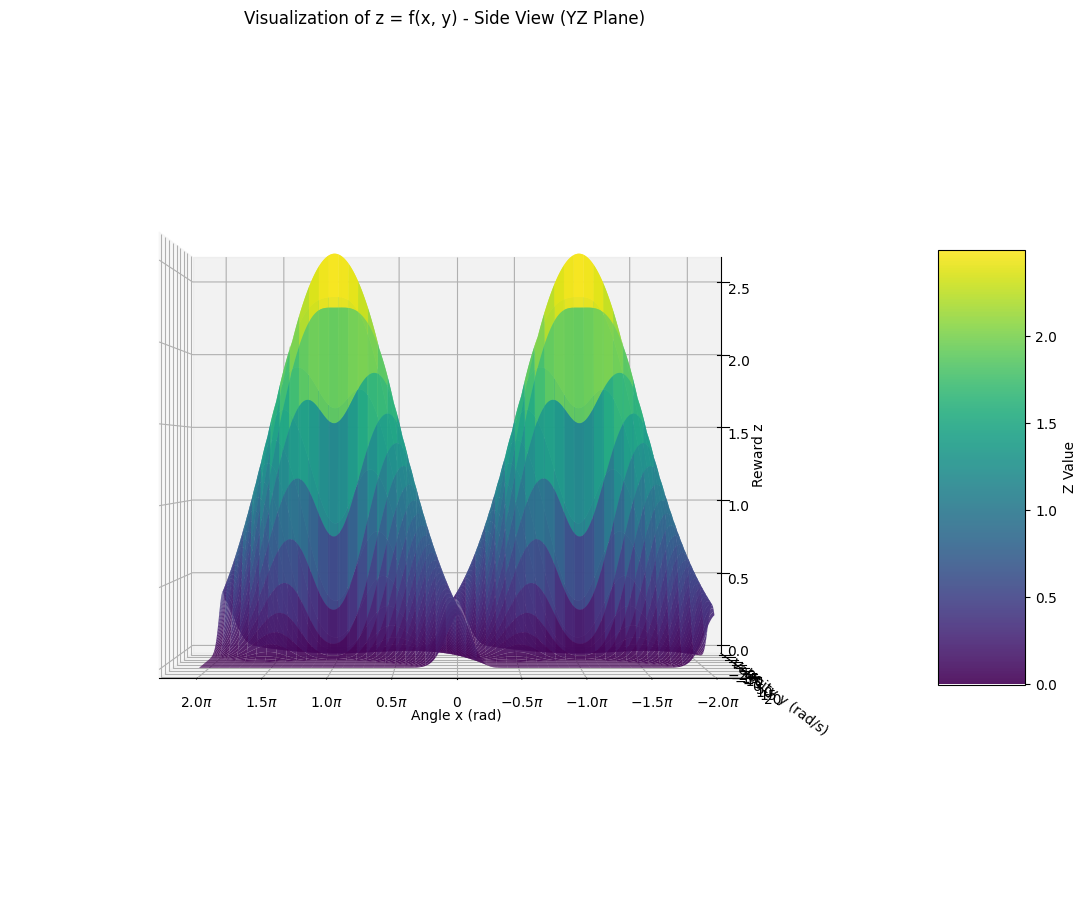

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Helper functions ---

def calculate_z(x, y):
    # Your exact parameters
    l = 3.8
    p = np.pi
    g_val = 2.16  # 'g' from your list
    f = -0.7     # Assumed from the second 'g = -1.2' in your list
    c = 5
    w = 7
    d = 1.6
    # Math Note: Because l (1.4) is a decimal, taking a negative number to the power of 1.4 
    # creates imaginary numbers in Python. We use np.abs() and np.sign() to safely keep the S-curve shape.
    
    # --- Blob 1: Using (y + p) ---
    base1 = f * (-x + p)
    power_term1 = np.sign(base1) * (np.abs(base1) ** l)
    
    s_curve1 = 3 * np.exp(-((y + power_term1)**2) / (c + w * (-x + p)**2))
    envelope1 = g_val * (1 / (d * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((-x + p) / d)**2)
    blob1 = s_curve1 * envelope1

    # --- Blob 2: Using (y - p) ---
    base2 = f * (-x - p)
    power_term2 = np.sign(base2) * (np.abs(base2) ** l)
    
    s_curve2 = 3 * np.exp(-((y + power_term2)**2) / (c + w * (-x - p)**2))
    envelope2 = g_val * (1 / (d * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((-x - p) / d)**2)
    blob2 = s_curve2 * envelope2

    # Combine the two blobs
    z_filtered = np.maximum(blob1, blob2)
    return z_filtered

# Function to calculate the minimum angular error
def calculate_error(current_th, target_th):
    return np.abs(((current_th - target_th + np.pi) % (2 * np.pi)) - np.pi)

# Helper function for 2D Gaussian
def gaussian_2d(val_x, val_y, mu_x, mu_y, sigma_x, sigma_y, rho, scale):
    # Ensure inputs are arrays, even if they are scalar
    val_x = np.atleast_1d(val_x)
    val_y = np.atleast_1d(val_y)
    mu = np.array([mu_x, mu_y])
    cov = np.array([[sigma_x**2, rho * sigma_x * sigma_y],
                    [rho * sigma_x * sigma_y, sigma_y**2]])
    inv_cov = np.linalg.inv(cov)
    det_cov = np.linalg.det(cov)
    diff_x = val_x - mu[0]
    diff_y = val_y - mu[1]
    exponent = -0.5 * (inv_cov[0,0] * diff_x**2 +
                        (inv_cov[0,1] + inv_cov[1,0]) * diff_x * diff_y +
                        inv_cov[1,1] * diff_y**2)

    return scale * (1.0 / (2 * np.pi * np.sqrt(det_cov))) * np.exp(exponent)

# --- Constants ---
A_VALUE = 3.25  
B_VALUE = 0.7  
J_VALUE = 2  

def reward_function_for_plot(th_val, omega_val, th_ref_val, u_val):
    main_reward_component = gaussian_2d(calculate_error(th_val, np.pi), omega_val, 0, 0, 1, 1, 0.0, 2)
    bottom_punishment_component = gaussian_2d(calculate_error(th_val, 0), omega_val, 0, 0, 3, 3, 0.0, 40)
    # peak_reward_component = gaussian_2d(calculate_error(th_val, np.pi), omega_val, 0, 0, 0.07, 0.07, 0.0, 0.15)
    peak_test = gaussian_2d(calculate_error(th_val, np.pi), omega_val, 0, 0, 0.15, 0.15, 0.0, 0.05)
    
    # Call your new exact formula
    Z_VALUES = calculate_z(th_val, omega_val)
    
    control_input_penalty = 0.001 * u_val**2
    
    # Combine all components
    total_reward = (
        # main_reward_component
        # - bottom_punishment_component
        - control_input_penalty
        + Z_VALUES
        # + peak_reward_component
        # + peak_test
    )
    return total_reward

# --- Plotting Section ---

# Define the ranges for the axes
# th_val: System angle, from -2pi to 2pi
th_plot_range = np.linspace(-2 * np.pi, 2 * np.pi, 400)
# omega_val: Angular velocity
omega_plot_range = np.linspace(-20, 20, 400) 

# Create the meshgrid
TH_MESH, OMEGA_MESH = np.meshgrid(th_plot_range, omega_plot_range)

# Static values for this specific plot
TH_REF_FOR_PLOT = 0.0 
U_FOR_PLOT = 0.5      

# Calculate rewards over the entire grid
Z_REWARD = reward_function_for_plot(TH_MESH, OMEGA_MESH, th_ref_val=TH_REF_FOR_PLOT, u_val=U_FOR_PLOT)

plot_views = [
    {'elev': 30, 'azim': -60, 'title_suffix': 'Standard View'},
    {'elev': 90, 'azim': 90, 'title_suffix': 'Top-Down View (XY Plane)'},
    {'elev': 0, 'azim': 0, 'title_suffix': 'Front View (XZ Plane)'},
    {'elev': 0, 'azim': 90, 'title_suffix': 'Side View (YZ Plane)'}
]

for i, view in enumerate(plot_views):
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    plt.tight_layout()

    ax.set_xlabel('Angle x (rad)')
    ax.set_ylabel('Velocity y (rad/s)')
    ax.set_zlabel('Reward z')
    ax.set_title(f'Visualization of z = f(x, y) - {view["title_suffix"]}')

    # --- Custom x-axis labels in multiples of pi ---
    x_tick_values = np.array([-2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2]) * np.pi
    ax.set_xticks(x_tick_values)
    
    x_tick_labels = [f'${val}\pi$' if val != 0 else '0' for val in x_tick_values / np.pi]
    ax.set_xticklabels(x_tick_labels)
    # --- End custom x-axis labels ---

    surf = ax.plot_surface(TH_MESH, OMEGA_MESH, Z_REWARD, cmap='viridis', edgecolor='none', alpha=0.9)
    fig.colorbar(surf, shrink=0.5, aspect=5, label='Z Value')

    ax.view_init(elev=view['elev'], azim=view['azim'])
    plt.show()